<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 62 · Sampling &amp; Data Collection</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Probability Sampling Methods 🎲</div>
  <div style="font-size:15px;color:#fff1f2;max-width:740px;line-height:1.6">When every unit has a known, non-zero chance of selection, the sample is representative and the error is calculable. We simulate the four workhorses, simple random, stratified, cluster, and systematic, and compare their precision.</div>
  <div style="margin-top:16px;font-size:13px;color:#fecdd3">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; a structured population

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROSE="#e11d48"; DEEP="#be123c"; LIGHT="#fb7185"; INK="#1a2138"; GRID="#e6e9f2"; TEAL="#0d9488"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
rng = np.random.default_rng(62)
# 100,000 people in 4 regions whose mean incomes differ a lot (strata matter)
region_means = {"North":42000, "South":55000, "East":68000, "West":90000}
sizes = {"North":40000, "South":30000, "East":20000, "West":10000}
rows=[]
for r,(m) in region_means.items():
    inc = rng.normal(m, 9000, sizes[r])
    rows.append(pd.DataFrame({"region":r, "income":inc}))
pop = pd.concat(rows, ignore_index=True)
MU = pop.income.mean()
print(f"population: N={len(pop):,}, true mean income = ${MU:,.0f}")
print(pop.groupby("region").income.agg(["size","mean"]).round(0))

population: N=100,000, true mean income = $55,862
         size     mean
region                
East    20000  68009.0
North   40000  41941.0
South   30000  54982.0
West    10000  89897.0


<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 1 · SIMPLE RANDOM SAMPLING (SRS)</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Every unit, an equal chance</div>
<div style="color:#4a5578;margin-top:6px">In SRS every one of the N units is equally likely, like drawing names from a hat. It is unbiased and the benchmark all other methods are judged against. We draw 2,000 SRS samples of n=500 and record the spread of the estimate.</div>
</div>

In [2]:
def srs(n): return pop.income.values[rng.choice(len(pop), n, replace=False)].mean()
srs_means = np.array([srs(500) for _ in range(2000)])
print(f"SRS (n=500): estimate = ${srs_means.mean():,.0f}  (true ${MU:,.0f})")
print(f"standard error (the spread of estimates) = ${srs_means.std():,.0f}")
SRS_SE = srs_means.std()

SRS (n=500): estimate = $55,836  (true $55,862)
standard error (the spread of estimates) = $789


SRS is unbiased: the average estimate lands on the truth. Its standard error is our baseline. Every method below is judged by whether it beats this spread for the same sample size.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 2 · STRATIFIED SAMPLING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Sample within each group, then combine</div>
<div style="color:#4a5578;margin-top:6px">Divide the population into strata (here, regions) and sample each one separately, in proportion to its size. Because each stratum is internally similar, the between-region differences no longer add noise, so the estimate is tighter.</div>
</div>

In [3]:
regions = list(region_means)
props = {r: sizes[r]/len(pop) for r in regions}
def stratified(n):
    parts=[]
    for r in regions:
        idx = pop.index[pop.region==r].values
        nr = round(n*props[r])                       # proportional allocation
        parts.append(pop.income.values[rng.choice(idx, nr, replace=False)])
    sample = np.concatenate(parts)
    return sample.mean()
strat_means = np.array([stratified(500) for _ in range(2000)])
print(f"Stratified (n=500): estimate = ${strat_means.mean():,.0f}")
print(f"standard error = ${strat_means.std():,.0f}  vs SRS ${SRS_SE:,.0f}")
print(f"variance reduction vs SRS: {(1-(strat_means.std()/SRS_SE)**2)*100:.0f}%")

Stratified (n=500): estimate = $55,851
standard error = $400  vs SRS $789
variance reduction vs SRS: 74%


Stratifying slashes the standard error. By guaranteeing every region is represented in the right proportion, it removes the between-region variation from the sampling error. Stratified sampling never does worse than SRS, and the more the strata differ, the bigger the win.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 3 · CLUSTER SAMPLING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Sample whole groups to save cost</div>
<div style="color:#4a5578;margin-top:6px">Sometimes reaching scattered individuals is expensive (travel, setup). Cluster sampling picks a few whole clusters (say, city blocks) and surveys everyone in them. It is cheap, but because a cluster's members are alike, it carries LESS information per unit, so variance rises.</div>
</div>

In [4]:
# carve the population into 1,000 clusters of 100 that each lean to one income band
pop_sorted = pop.sort_values("income").reset_index(drop=True)
pop_sorted["cluster"] = pop_sorted.index // 100        # neighbors are similar (homogeneous clusters)
def cluster_sample(n_clusters=5):
    chosen = rng.choice(pop_sorted.cluster.max()+1, n_clusters, replace=False)
    return pop_sorted.income[pop_sorted.cluster.isin(chosen)].mean()
clus_means = np.array([cluster_sample(5) for _ in range(2000)])   # 5 clusters x 100 = 500 units
print(f"Cluster (5 clusters x 100 = n=500): estimate = ${clus_means.mean():,.0f}")
print(f"standard error = ${clus_means.std():,.0f}  vs SRS ${SRS_SE:,.0f}")
print("same sample size, but FAR noisier: homogeneous clusters waste information")

Cluster (5 clusters x 100 = n=500): estimate = $55,830
standard error = $7,847  vs SRS $789
same sample size, but FAR noisier: homogeneous clusters waste information


Cluster sampling trades precision for cost. With the same 500 units its error is much larger than SRS, because members of a cluster resemble one another, so 100 people from one cluster are worth far fewer than 100 independent draws. You accept this when the cost savings outweigh the precision loss.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 4 · SYSTEMATIC SAMPLING & THE PERIODICITY TRAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Every k-th unit, beware hidden cycles</div>
<div style="color:#4a5578;margin-top:6px">Systematic sampling takes every k-th unit after a random start. On a randomly ordered list it behaves like SRS and is easy to run. But if the list has a cycle that lines up with k, the sample can be badly biased.</div>
</div>

In [5]:
N=len(pop); n=500; k=N//n
def systematic_random_order():
    order = rng.permutation(N)                     # randomly ordered list
    start = rng.integers(k)
    return pop.income.values[order[start::k]][:n].mean()
sys_means = np.array([systematic_random_order() for _ in range(2000)])
print(f"Systematic on a RANDOM order (every k={k}th): SE = ${sys_means.std():,.0f}  ~ SRS ${SRS_SE:,.0f}\n")
# the trap: a periodic list (incomes repeating in a cycle of length k)
cycle = np.tile(np.linspace(30000, 90000, k), N//k + 1)[:N]
start = 0
trap_estimate = cycle[start::k][:n].mean()
print(f"PERIODICITY TRAP: list cycles with period k -> every k-th value is identical")
print(f"systematic estimate = ${trap_estimate:,.0f}, true ${cycle.mean():,.0f}  -> badly biased")

Systematic on a RANDOM order (every k=200th): SE = $794  ~ SRS $789

PERIODICITY TRAP: list cycles with period k -> every k-th value is identical
systematic estimate = $30,000, true $60,000  -> badly biased


On a shuffled list, systematic sampling matches SRS and is simpler to administer. The danger is a hidden period: if the ordering repeats with a cycle that matches the step k, every selected unit can share the same trait, and the estimate is wildly off. Always check the list for structure before stepping through it.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 5 · COMPARING ALL FOUR</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Same n, very different precision</div>
<div style="color:#4a5578;margin-top:6px">Side by side, the four methods on the same population and sample size make the trade-offs obvious: stratified is tightest, cluster is loosest, SRS and systematic sit in between.</div>
</div>

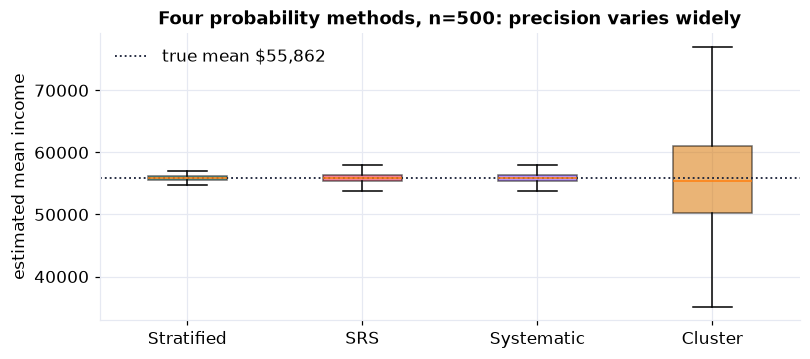

 Stratified: SE = $400
        SRS: SE = $789
 Systematic: SE = $794
    Cluster: SE = $7,847


In [6]:
fig,ax=plt.subplots(figsize=(7.5,3.4))
data=[strat_means, srs_means, sys_means, clus_means]
labels=["Stratified","SRS","Systematic","Cluster"]
cols=[TEAL, ROSE, "#7c3aed", "#d97706"]
bp=ax.boxplot(data, tick_labels=labels, patch_artist=True, showfliers=False)
for patch,c in zip(bp["boxes"],cols): patch.set_facecolor(c); patch.set_alpha(0.55)
ax.axhline(MU, color=INK, ls=":", lw=1.2, label=f"true mean ${MU:,.0f}")
ax.set_ylabel("estimated mean income"); ax.set_title("Four probability methods, n=500: precision varies widely"); ax.legend()
plt.tight_layout(); plt.show()
for lab,d in zip(labels,data): print(f"{lab:>11}: SE = ${d.std():,.0f}")

All four are unbiased (centered on the truth), but their precision differs sharply. The art of sampling design is choosing the method whose cost and precision fit the problem, and stratifying whenever you have a grouping variable that matters.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Probability sampling</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Every probability method gives an unbiased estimate, but precision varies: stratified sampling beats SRS by removing between-group variation, cluster sampling sacrifices precision for cost, and systematic sampling matches SRS unless a hidden period bites. Known selection probabilities are what make the error calculable, the property non-probability methods lack.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>